### описание
Добавить в Random Forest и Gradient Boosting выбор случайного набора фичей для построения каждого отдельного дерева.

**Необходимо** использовать реализованные деревья из прошлой домашки (реализовать для задачи регрессии)



In [101]:
import numpy as np
from tqdm.auto import tqdm
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from typing import Literal
from itertools import combinations
from sklearn.metrics import r2_score

In [102]:
RANDOM_STATE = 69
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

In [103]:
RESULTS = {}

### 1. классы

In [104]:
class MyRegressionTree:
    def __init__(
        self,
        max_leaves=None,
        min_samples_leaf=1,
        min_impurity_decrease=0.0,
    ):
        self.max_leaves = max_leaves
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.root = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "value": None,
            "categorical": False,
            "categories": None,
        }
        self.feature_names = None
        self.n_leaves = 0

    def _criterion_func(self, values):
        if len(values) == 0:
            return 0
        return np.var(values) * len(values)

    def _is_categorical(self, values):
        return isinstance(values[0], (str, bool)) or len(set(values)) < 10

    def _split_data(
        self, X, y, feature_idx, threshold, categorical=False, categories=None
    ):
        if categorical:
            mask = np.array([x[feature_idx] in categories for x in X])
        else:
            mask = np.array([x[feature_idx] <= threshold for x in X])

        X_left, y_left = X[mask], y[mask]
        X_right, y_right = X[~mask], y[~mask]

        return X_left, y_left, X_right, y_right

    def _find_best_split_regression(self, values, targets):
        sorted_pairs = sorted(list(zip(values, targets)), key=lambda x: x[0])

        n = len(sorted_pairs)
        total_mse = self._criterion_func(targets)

        best_mse = total_mse
        best_split = None

        left_values = []
        right_values = sorted_pairs.copy()

        for i in range(1, len(sorted_pairs)):
            if sorted_pairs[i][0] == sorted_pairs[i - 1][0]:
                continue

            left_values.append(right_values.pop(0))

            split_val = (sorted_pairs[i - 1][0] + sorted_pairs[i][0]) / 2

            left_targets = [v[1] for v in left_values]
            right_targets = [v[1] for v in right_values]

            left_mse = self._criterion_func(left_targets)
            right_mse = self._criterion_func(right_targets)

            split_mse = left_mse + right_mse

            if split_mse < best_mse:
                best_mse = split_mse
                best_split = split_val

        return (best_split, best_mse)

    def _find_best_categorical_split_regression(
        self, values, targets, max_categories=5
    ):
        unique_cats = list(set(values))
        n = len(values)
        total_mse = self._criterion_func(targets)

        best_mse = total_mse
        best_split = None

        if len(unique_cats) <= max_categories:
            possible_splits = []
            for i in range(1, len(unique_cats)):
                possible_splits.extend(combinations(unique_cats, i))

            for split_cats in possible_splits:
                split_cats = set(split_cats)
                left_indices = [i for i, v in enumerate(values) if v in split_cats]
                right_indices = [i for i, v in enumerate(values) if v not in split_cats]

                if not left_indices or not right_indices:
                    continue

                left_targets = [targets[i] for i in left_indices]
                right_targets = [targets[i] for i in right_indices]

                left_mse = self._criterion_func(left_targets)
                right_mse = self._criterion_func(right_targets)

                split_mse = left_mse + right_mse

                if split_mse < best_mse:
                    best_mse = split_mse
                    best_split = split_cats
        else:
            for cat in unique_cats:
                split_cats = {cat}
                left_indices = [i for i, v in enumerate(values) if v in split_cats]
                right_indices = [i for i, v in enumerate(values) if v not in split_cats]

                if not left_indices or not right_indices:
                    continue

                left_targets = [targets[i] for i in left_indices]
                right_targets = [targets[i] for i in right_indices]

                left_mse = self._criterion_func(left_targets)
                right_mse = self._criterion_func(right_targets)

                split_mse = left_mse + right_mse

                if split_mse < best_mse:
                    best_mse = split_mse
                    best_split = split_cats

        return (best_split, best_mse)

    def _build_tree(self, X, y, depth=0, node=None):
        if node is None:
            node = self.root

        # Terminal conditions
        if (
            len(X) < 2 * self.min_samples_leaf
            or np.var(y) < self.min_impurity_decrease
            or (self.max_leaves is not None and self.n_leaves >= self.max_leaves)
        ):
            self.n_leaves += 1
            node["value"] = np.mean(y)
            return

        best_feature = None
        best_threshold = None
        best_mse = float("inf")
        is_categorical = False
        categories = None

        for feature_idx in range(X.shape[1]):
            values = X[:, feature_idx]

            if self._is_categorical(values):
                split_info = self._find_best_categorical_split_regression(values, y)
                if split_info[0] is not None and split_info[1] < best_mse:
                    best_feature = feature_idx
                    best_threshold = None
                    best_mse = split_info[1]
                    is_categorical = True
                    categories = split_info[0]
            else:
                split_info = self._find_best_split_regression(values, y)
                if split_info[0] is not None and split_info[1] < best_mse:
                    best_feature = feature_idx
                    best_threshold = split_info[0]
                    best_mse = split_info[1]
                    is_categorical = False
                    categories = None

        if best_feature is None:
            self.n_leaves += 1
            node["value"] = np.mean(y)
            return

        node["feature_name"] = (
            self.feature_names[best_feature]
            if self.feature_names is not None
            else best_feature
        )
        node["feature_idx"] = best_feature
        node["threshold"] = best_threshold
        node["categorical"] = is_categorical
        node["categories"] = categories

        X_left, y_left, X_right, y_right = self._split_data(
            X, y, best_feature, best_threshold, is_categorical, categories
        )

        if len(X_left) < self.min_samples_leaf or len(X_right) < self.min_samples_leaf:
            self.n_leaves += 1
            node["value"] = np.mean(y)
            return

        node["left_child"] = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "value": None,
            "categorical": False,
            "categories": None,
        }
        node["right_child"] = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "value": None,
            "categorical": False,
            "categories": None,
        }

        self._build_tree(X_left, y_left, depth + 1, node["left_child"])
        self._build_tree(X_right, y_right, depth + 1, node["right_child"])

    def fit(self, X_train, y_train, feature_names=None):
        self.feature_names = feature_names
        self.n_leaves = 0
        self.root = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "value": None,
            "categorical": False,
            "categories": None,
        }

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        self._build_tree(X_train, y_train)
        return self

    def _predict_one(self, x, node=None):
        if node is None:
            node = self.root

        if node["value"] is not None:
            return node["value"]

        feature_idx = node["feature_idx"]

        if node["categorical"]:
            if x[feature_idx] in node["categories"]:
                return self._predict_one(x, node["left_child"])
            else:
                return self._predict_one(x, node["right_child"])
        else:
            if x[feature_idx] <= node["threshold"]:
                return self._predict_one(x, node["left_child"])
            else:
                return self._predict_one(x, node["right_child"])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])

In [105]:
class MyRandomForestRegressor:
    def __init__(
        self,
        num_trees=10,
        max_depth=5,
        features_by_tree_strategy: Literal[
            "half",
            "sqrt",
            "other",
        ] = "sqrt",
    ):
        self.num_trees = num_trees
        self.max_depth = max_depth
        self.features_by_tree_strategy = features_by_tree_strategy

    def fit(self, X, y):
        self.trees = []

        n_cols = X.shape[1]

        if self.features_by_tree_strategy == "sqrt":
            n_cols_by_tree = int(np.ceil(n_cols**0.5))
        elif self.features_by_tree_strategy == "half":
            n_cols_by_tree = int(np.ceil(n_cols * 0.5))
        else:
            n_cols_by_tree = n_cols

        for i in range(self.num_trees):
            n_samples = X.shape[0]
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]

            selected_features = np.random.choice(
                n_cols, min(n_cols_by_tree, n_cols), replace=False
            )

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X_bootstrap[:, selected_features], y_bootstrap)

            self.trees.append((tree, selected_features))

    def predict(self, X):
        predicts = []

        for i, (tree, selected_features) in enumerate(self.trees):
            tree_prediction = tree.predict(X[:, selected_features])
            predicts.append(tree_prediction)

        answer = np.mean(predicts, axis=0)
        return answer

In [106]:
class MyGBDTRegressor:
    def __init__(
        self,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        features_by_tree_strategy: Literal[
            "half",
            "sqrt",
            "other",
        ] = "sqrt",
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.features_by_tree_strategy = features_by_tree_strategy
        self.trees = []
        self.selected_features_list = []
        self.base_prediction = None

    def fit(self, X, y):
        self.trees = []
        self.selected_features_list = []

        self.base_prediction = np.mean(y)
        predictions = np.full_like(y, self.base_prediction, dtype=float)

        n_cols = X.shape[1]

        if self.features_by_tree_strategy == "sqrt":
            n_cols_by_tree = int(np.ceil(n_cols**0.5))
        elif self.features_by_tree_strategy == "half":
            n_cols_by_tree = int(np.ceil(n_cols * 0.5))
        else:
            n_cols_by_tree = n_cols

        for i in tqdm(range(self.n_estimators)):
            residuals = y - predictions

            selected_features = np.random.choice(
                n_cols, min(n_cols_by_tree, n_cols), replace=False
            )
            self.selected_features_list.append(selected_features)

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X[:, selected_features], residuals)
            self.trees.append(tree)

            tree_pred = tree.predict(X[:, selected_features])
            predictions += self.learning_rate * tree_pred

        return self

    def predict(self, X):
        predictions = np.full(X.shape[0], self.base_prediction, dtype=float)

        for i, tree in enumerate(self.trees):
            selected_features = self.selected_features_list[i]
            predictions += self.learning_rate * tree.predict(X[:, selected_features])

        return predictions

### 2. сравнение

In [107]:
def do_metrics(true, preds, probas=None, precision=4):
    r2 = r2_score(true, preds)
    mse_score = np.mean((true - preds) ** 2)

    print(f"R2: {r2:.{precision}f}")
    print(f"MSE: {mse_score:.{precision}f}")

    return {
        "R2": r2,
        "MSE": mse_score,
    }

In [108]:
def fit_predict_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    RESULTS[name] = {
        "train": do_metrics(y_train, train_preds),
        "test": do_metrics(y_test, test_preds),
    }

In [109]:
src = fetch_california_housing()

In [110]:
df = pd.DataFrame(src["data"], columns=src["feature_names"])
df["target"] = src["target"]

In [111]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [112]:
features = src["feature_names"]
target = "target"

In [113]:
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [114]:
sk_tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=RANDOM_STATE,
)
fit_predict_model(
    "sk_tree",
    sk_tree,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

my_tree = MyRegressionTree(
    max_leaves=10,
    min_samples_leaf=5,
    min_impurity_decrease=0.01,
)
fit_predict_model(
    "my_tree",
    my_tree,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

R2: 0.6342
MSE: 0.4849
R2: 0.6049
MSE: 0.5315
R2: 0.0198
MSE: 1.2993
R2: 0.0224
MSE: 1.3151


In [115]:
my_rf = MyRandomForestRegressor(
    num_trees=10,
    max_depth=5,
    features_by_tree_strategy="sqrt",
)
fit_predict_model(
    "my_rf_sqrt",
    my_rf,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

my_rf_half = MyRandomForestRegressor(
    num_trees=10,
    max_depth=5,
    features_by_tree_strategy="half",
)
fit_predict_model(
    "my_rf_half",
    my_rf_half,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)
my_rf_other = MyRandomForestRegressor(
    num_trees=10,
    max_depth=5,
    features_by_tree_strategy="other",
)
fit_predict_model(
    "my_rf_other",
    my_rf_other,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

R2: 0.5928
MSE: 0.5397
R2: 0.5764
MSE: 0.5699
R2: 0.6483
MSE: 0.4662
R2: 0.6323
MSE: 0.4946
R2: 0.6794
MSE: 0.4250
R2: 0.6499
MSE: 0.4710


In [116]:
sk_rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    random_state=RANDOM_STATE,
)
fit_predict_model(
    "sk_rf",
    sk_rf,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

R2: 0.6803
MSE: 0.4238
R2: 0.6529
MSE: 0.4669


In [117]:
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)
fit_predict_model(
    "lgbm",
    lgbm,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

my_gbdt = MyGBDTRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    features_by_tree_strategy="sqrt",
)
fit_predict_model(
    "my_gbdt",
    my_gbdt,
    X_train.values,
    y_train.values,
    X_test.values,
    y_test.values,
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 8
[LightGBM] [Info] Start training from score 2.064217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

  0%|          | 0/100 [00:00<?, ?it/s]

R2: 0.7846
MSE: 0.2855
R2: 0.7536
MSE: 0.3315


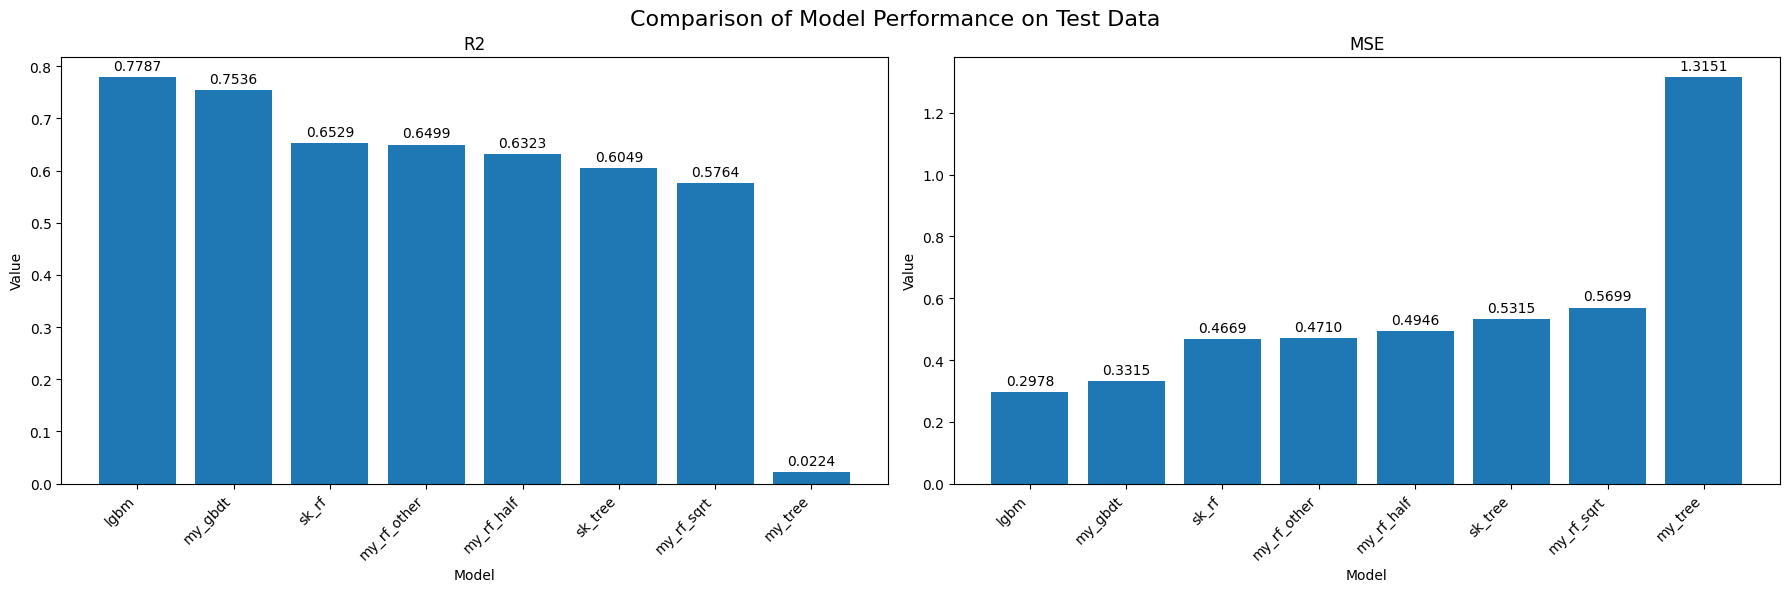

In [ ]:
metrics = ["R2", "MSE"]
models = list(RESULTS.keys())

comparison_data = []
for model in models:
    for metric in metrics:
        comparison_data.append(
            {"Model": model, "Metric": metric, "Value": RESULTS[model]["test"][metric]}
        )

df_comparison = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Comparison of Model Performance on Test Data", fontsize=16)

for i, metric in enumerate(metrics):
    metric_data = df_comparison[df_comparison["Metric"] == metric]

    if metric == "MSE":
        metric_data = metric_data.sort_values("Value")
    else:
        metric_data = metric_data.sort_values("Value", ascending=False)

    bars = axes[i].bar(metric_data["Model"], metric_data["Value"])
    axes[i].set_title(metric)
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel("Value")

    axes[i].set_xticklabels(metric_data["Model"], rotation=45, ha="right")

    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(
            f"{height:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=0,
        )

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()